# Housing Affordability & Rent Burden Analysis — England (2019–2025)

**Author:** Deepika Sivakumar 

**Data sources:** ONS Private Rental Market Statistics, ASHE Median Earnings  

**Coverage:** 281 English local authorities, 2019–2025  

## Project overview
This notebook analyses private rental affordability for **individual renters** across English local authorities (LAs), using median rent for single-occupancy properties against median individual earnings.

**Target population:** Single renters-individuals living alone in rooms, 
studios, or one-bedroom properties.

**Affordability threshold:** 30% of gross monthly income spent on rent.

## Data sources
| Dataset | Source | Years | Geography |
|---|---|---|---|
| Private rental prices | ONS / VOA | 2019–2025 | Local Authority |
| Annual earnings | ASHE (ONS) | 2019–2025 | Local Authority |

### Importing of Libraries

In [357]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

In [358]:
from pathlib import Path

data_directory = Path("D:/Housing")
processed_directory = Path("D:/Housing/processed")
rent_files_1 = [data_directory/"rent/rent_18-19.xls",
                data_directory/"rent/rent_19-20.xls",
                data_directory/"rent/rent_20-21.xls",
                data_directory/"rent/rent_21-22.xls"]

rent_files_2 = data_directory/"rental.xlsx"

salary_files = [data_directory/"salary/salary_2019.xls",
                data_directory/"salary/salary_2020.xls",
                data_directory/"salary/salary_2021.xls",
                data_directory/"salary/salary_2022.xls",
                data_directory/"salary/salary_2023.xlsx",
                data_directory/"salary/salary_2024.xlsx",
                data_directory/"salary/salary_2025.xlsx"]

## 1. Data Loading and Data Cleaning
### 1a. Rent data - 2019 to 2022(ONS Private Rental Market Statistics)
Three types of room categories (single room, studio, one-bedroom) are extracted.
Median rent is calculated across the categories to produce single monthly rent.


In [359]:
target_sheets = ["Table2.1", "Table2.2", "Table2.3"]

start_row = 7
end_row = 378
all_rent_data = {}

def extract_sheets(file_path, sheets, start_row, end_row):
    extracted={}
    rows_to_read = end_row-start_row+1

    for sheet in sheets:
        try:
            df = pd.read_excel(file_path, 
                               sheet_name=sheet, 
                               skiprows=start_row-1, 
                               nrows=rows_to_read,
                            usecols='B:I')
            
            extracted[sheet] = df
            print(f"Loaded {sheet} from {file_path}")
        except Exception as e:
            print(f"Could not load {sheet} from {file_path}: {e}")
    return extracted
    
for file in rent_files_1:
    all_rent_data[file.name] = extract_sheets(file, 
                                         target_sheets, 
                                         start_row, 
                                         end_row)



Loaded Table2.1 from D:\Housing\rent\rent_18-19.xls
Loaded Table2.2 from D:\Housing\rent\rent_18-19.xls
Loaded Table2.3 from D:\Housing\rent\rent_18-19.xls
Loaded Table2.1 from D:\Housing\rent\rent_19-20.xls
Loaded Table2.2 from D:\Housing\rent\rent_19-20.xls
Loaded Table2.3 from D:\Housing\rent\rent_19-20.xls
Loaded Table2.1 from D:\Housing\rent\rent_20-21.xls
Loaded Table2.2 from D:\Housing\rent\rent_20-21.xls
Loaded Table2.3 from D:\Housing\rent\rent_20-21.xls
Loaded Table2.1 from D:\Housing\rent\rent_21-22.xls
Loaded Table2.2 from D:\Housing\rent\rent_21-22.xls
Loaded Table2.3 from D:\Housing\rent\rent_21-22.xls


In [360]:
for file, sheets in all_rent_data.items():
    for sheet, df in sheets.items():
        print(file, sheet, df.shape)
        print(df.columns)

rent_18-19.xls Table2.1 (372, 8)
Index(['LA Code1', 'Area Code1', 'Area', 'Count of rents', 'Mean',
       'Lower quartile', 'Median', 'Upper quartile'],
      dtype='object')
rent_18-19.xls Table2.2 (372, 8)
Index(['LA Code1', 'Area Code1', 'Area', 'Count of rents', 'Mean',
       'Lower quartile', 'Median', 'Upper quartile'],
      dtype='object')
rent_18-19.xls Table2.3 (372, 8)
Index(['LA Code1', 'Area Code1', 'Area', 'Count of rents', 'Mean',
       'Lower quartile', 'Median', 'Upper quartile'],
      dtype='object')
rent_19-20.xls Table2.1 (372, 8)
Index(['LA Code1', 'Area Code1', 'Area', 'Count of rents', 'Mean',
       'Lower quartile', 'Median', 'Upper quartile'],
      dtype='object')
rent_19-20.xls Table2.2 (372, 8)
Index(['LA Code1', 'Area Code1', 'Area', 'Count of rents', 'Mean',
       'Lower quartile', 'Median', 'Upper quartile'],
      dtype='object')
rent_19-20.xls Table2.3 (372, 8)
Index(['LA Code1', 'Area Code1', 'Area', 'Count of rents', 'Mean',
       'Lower quarti

In [361]:
for k, v in all_rent_data.items():
    print(type(v))

<class 'dict'>
<class 'dict'>
<class 'dict'>
<class 'dict'>


### 1b. Rent data Cleaning - 2019 to 2022

Columns are renamed, Median rent is chosen

In [362]:
combined = []

for file, sheet in all_rent_data.items():
    for sheet, df in sheet.items():
        temp = df.copy()
        
        temp = temp.rename(columns={
            "LA Code1": "la_code",
            "Area Code1": "area_code",
            "Area": "area",
            "Count of rents": "rent_count",
            "Mean": "mean_rent",
            "Lower Quartile": "lower_quartile",
            "Median": "median_rent",
            "Upper Quartile": "upper_quartile",
        })
        year = file.replace("rent_", "").replace(".xls", "")
        temp["Year"] = year
        

        combined.append(temp)

rent_df = pd.concat(combined, ignore_index=True)
print(rent_df.head())
print(rent_df.columns)
print(rent_df.shape)

   la_code  area_code              area rent_count mean_rent Lower quartile  \
0      NaN  E92000001           ENGLAND      22590       417            350   
1      NaN  E12000001        NORTH EAST       1010       363            325   
2   1355.0  E06000047  County Durham UA         60       394            303   
3   1350.0  E06000005     Darlington UA         70       312            303   
4    724.0  E06000001     Hartlepool UA          0         .              .   

  median_rent Upper quartile   Year  
0         396            455  18-19  
1         351            386  18-19  
2         368            450  18-19  
3         303            303  18-19  
4           .              .  18-19  
Index(['la_code', 'area_code', 'area', 'rent_count', 'mean_rent',
       'Lower quartile', 'median_rent', 'Upper quartile', 'Year'],
      dtype='object')
(4464, 9)


In [363]:
rent_df = rent_df.dropna(
    subset=['la_code', 'area_code'],
    how="all"
)

In [364]:
rent_df = rent_df[
    rent_df["la_code"].notna() &
    rent_df["area_code"].notna()    
]

In [365]:
print(rent_df.tail(10))

      la_code  area_code                       area rent_count mean_rent  \
4438   1605.0  E07000078                 Cheltenham      580.0     646.0   
4439   1610.0  E07000079                   Cotswold      210.0     706.0   
4440   1615.0  E07000080             Forest of Dean       70.0     506.0   
4441   1620.0  E07000081                 Gloucester      100.0     594.0   
4442   1625.0  E07000082                     Stroud      160.0     594.0   
4443   1630.0  E07000083                 Tewkesbury      150.0     564.0   
4445   3305.0  E07000187                     Mendip      210.0     587.0   
4446   3310.0  E07000188                  Sedgemoor      180.0     561.0   
4447   3330.0  E07000246  Somerset West and Taunton      280.0     563.0   
4448   3325.0  E07000189             South Somerset      400.0     535.0   

     Lower quartile median_rent Upper quartile   Year  
4438          550.0       650.0          725.0  21-22  
4439          625.0       695.0          775.0  21-

In [366]:
rent_df.columns = [
    "la_code",
    "area_code",
    "area",
    "rent_count",
    "mean_rent",
    "lower_quartile",
    "monthly_median_rent",
    "upper_quartile",
    "year"
]

In [367]:
print(rent_df.dtypes)

la_code                float64
area_code               object
area                    object
rent_count              object
mean_rent               object
lower_quartile          object
monthly_median_rent     object
upper_quartile          object
year                    object
dtype: object


In [368]:
numeric_cols = [
    "rent_count",
    "mean_rent",
    "lower_quartile",
    "monthly_median_rent",
    "upper_quartile"
]
for col in numeric_cols:
    rent_df[col]=pd.to_numeric(rent_df[col], errors='coerce')

In [369]:
rent_df.dtypes

la_code                float64
area_code               object
area                    object
rent_count             float64
mean_rent              float64
lower_quartile         float64
monthly_median_rent    float64
upper_quartile         float64
year                    object
dtype: object

In [370]:
rent_df["code_prefix"] = rent_df["area_code"].str[:3]

In [371]:
print(
    rent_df.groupby(["year", "code_prefix"])["area_code"]
    .nunique()
)

year   code_prefix
18-19  E06             56
       E07            201
       E08             36
       E09             33
19-20  E06             56
       E07            188
       E08             36
       E09             33
20-21  E06             56
       E07            188
       E08             36
       E09             33
21-22  E06             56
       E07            188
       E08             36
       E09             33
Name: area_code, dtype: int64


In [372]:
e07_2019 = set(
    rent_df[
        (rent_df["year"] == 2019) &
        (rent_df["code_prefix"] == "E07")
    ]["area_code"]
)

e07_2020 = set(
    rent_df[
        (rent_df["year"] == 2020) &
        (rent_df["code_prefix"] == "E07")
    ]["area_code"]
)

extra_2019 = e07_2019 - e07_2020

print(extra_2019)

set()


In [373]:
common_areas = set.intersection(
    *[
        set(rent_df[rent_df["year"] == y]["area_code"])
        for y in rent_df["year"].unique()
    ]
)

rent_df = rent_df[
    rent_df["area_code"].isin(common_areas)
]

In [374]:
rent_df.groupby("year")["area_code"].nunique()

year
18-19    308
19-20    308
20-21    308
21-22    308
Name: area_code, dtype: int64

In [375]:
rent_df = rent_df.dropna(subset=["la_code"])

In [376]:
rent_df["year"] = rent_df["year"].map({
    "18-19": 2019,
    "19-20": 2020,
    "20-21": 2021,
    "21-22": 2022
})

In [377]:
rent_data = rent_df[["area_code", "area", "rent_count", "monthly_median_rent","year"]]

In [378]:
rent_data.isna().sum()

area_code                0
area                     0
rent_count             348
monthly_median_rent    541
year                     0
dtype: int64

In [379]:
rent_data[rent_data["monthly_median_rent"].isna()].head(20)

,area_code,area,rent_count,monthly_median_rent,year
4,E06000001,Hartlepool UA,0.0,NaN,2019
8,E06000004,Stockton-on-Tees UA,NaN,NaN,2019
23,E07000026,Allerdale,NaN,NaN,2019
37,E08000008,Tameside,NaN,NaN,2019
43,E07000119,Fylde,NaN,NaN,2019
44,E07000120,Hyndburn,NaN,NaN,2019
46,E07000122,Pendle,NaN,NaN,2019
48,E07000124,Ribble Valley,0.0,NaN,2019
49,E07000125,Rossendale,0.0,NaN,2019
54,E08000011,Knowsley,NaN,NaN,2019


In [380]:
rent_data = rent_data.dropna(subset=["monthly_median_rent"])
print(rent_data.shape)

(3155, 5)


In [381]:
rent_data.groupby("year")["area_code"].nunique()

year
2019    307
2020    308
2021    308
2022    308
Name: area_code, dtype: int64

In [382]:
rent_data = rent_data.drop(columns=["rent_count"])

In [383]:
print(rent_data.columns)

Index(['area_code', 'area', 'monthly_median_rent', 'year'], dtype='object')


### 1c. Rent data - 2023-2025 (VOA)

Properties with 1-bedroom category only is chosen for this period, because of  data unavailability. Filtered only the England data using area code.

In [384]:
years = pd.read_excel(data_directory/rent_files_2, sheet_name = "Table 1", skiprows=2)

In [385]:
print(years.columns)

Index(['Time period', 'Area code', 'Area name', 'Region or country name',
       'Index', 'Monthly change', 'Annual change', 'Rental price',
       'Index one bed', 'Monthly change one bed', 'Annual change one bed',
       'Rental price one bed', 'Index two bed', 'Monthly change two bed',
       'Annual change two bed', 'Rental price two bed', 'Index three bed',
       'Monthly change three bed', 'Annual change three bed',
       'Rental price three bed', 'Index four or more bed',
       'Monthly change four or more bed', 'Annual change four or more bed',
       'Rental price four or more bed', 'Index detached',
       'Monthly change detached', 'Annual change detached',
       'Rental price detached', 'Index semidetached',
       'Monthly change semidetached', 'Annual change semidetached',
       'Rental price semidetached', 'Index terraced',
       'Monthly change terraced', 'Annual change terraced',
       'Rental price terraced', 'Index flat maisonette',
       'Monthly change flat

In [386]:
years=years[["Time period","Area code", "Area name", "Rental price one bed"]]

In [387]:
years["month-year"] = pd.to_datetime(years["Time period"])

In [388]:
years["year"] = years["month-year"].dt.year
years = years.drop(columns=["Time period", "month-year"])

In [389]:
print(years)

       Area code                         Area name Rental price one bed  year
0      K02000001                    United Kingdom                  736  2015
1      K02000001                    United Kingdom                  738  2015
2      K02000001                    United Kingdom                  740  2015
3      K02000001                    United Kingdom                  744  2015
4      K02000001                    United Kingdom                  748  2015
...          ...                               ...                  ...   ...
48547        [z]  South West Northern Ireland BRMA                  485  2025
48548        [z]  South West Northern Ireland BRMA                  486  2026
48549        [z]  South West Northern Ireland BRMA                  487  2026
48550        [z]  South West Northern Ireland BRMA                  [x]  2026
48551        [z]  South West Northern Ireland BRMA                  [x]  2026

[48552 rows x 4 columns]


In [390]:
years = years[years["year"].between(2023, 2025)]

In [391]:
england = years[years["Area code"].str.startswith("E0")]

In [392]:
years = england.groupby(["Area code", "Area name", "year"],
    as_index=False
    )["Rental price one bed"].median()


In [393]:
print(years.columns)

Index(['Area code', 'Area name', 'year', 'Rental price one bed'], dtype='object')


In [394]:
print(years.head())

   Area code      Area name  year Rental price one bed
0  E06000001     Hartlepool  2023                371.0
1  E06000001     Hartlepool  2024                381.0
2  E06000001     Hartlepool  2025                398.0
3  E06000002  Middlesbrough  2023                398.0
4  E06000002  Middlesbrough  2024                429.5


In [395]:
years.columns=["area_code", "area", "year", "monthly_median_rent"]

In [396]:
print(type(rent_data))
print(type(years))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [397]:
years = years[years["area_code"].str.startswith("E0")]

In [398]:
rent_data = pd.DataFrame(rent_data)
balance_year = pd.DataFrame(years)

In [399]:
print(rent_data.dtypes)
print(balance_year.dtypes)

area_code               object
area                    object
monthly_median_rent    float64
year                     int64
dtype: object
area_code              object
area                   object
year                    int32
monthly_median_rent    object
dtype: object


In [400]:
balance_year["monthly_median_rent"]=pd.to_numeric(balance_year["monthly_median_rent"], errors='coerce')

In [401]:
final_rental = pd.concat([rent_data, balance_year], ignore_index=True)

In [402]:
print(final_rental.head(10))
print(final_rental.shape)
print(final_rental.isna().sum())

   area_code                     area  monthly_median_rent  year
0  E06000047         County Durham UA                368.0  2019
1  E06000005            Darlington UA                303.0  2019
2  E06000002         Middlesbrough UA                347.0  2019
3  E06000057        Northumberland UA                388.0  2019
4  E06000003  Redcar and Cleveland UA                305.0  2019
5  E08000037                Gateshead                368.0  2019
6  E08000021      Newcastle upon Tyne                385.0  2019
7  E08000022           North Tyneside                388.0  2019
8  E08000023           South Tyneside                390.0  2019
9  E08000024               Sunderland                368.0  2019
(4037, 4)
area_code              0
area                   0
monthly_median_rent    0
year                   0
dtype: int64


In [403]:
final_rental.groupby("year")["area_code"].nunique()

year
2019    307
2020    308
2021    308
2022    308
2023    294
2024    294
2025    294
Name: area_code, dtype: int64

In [404]:
common_areas = set.intersection(
    *[
        set(final_rental[final_rental["year"] == y]["area_code"])
        for y in final_rental["year"].unique()
    ]
)

final_rental = final_rental[
    final_rental["area_code"].isin(common_areas)
]

In [405]:
print(final_rental.groupby("year")["area_code"].nunique())

year
2019    281
2020    281
2021    281
2022    281
2023    281
2024    281
2025    281
Name: area_code, dtype: int64


### 1d. Salary data — 2019–2025 (ASHE, ONS)

Annual Survey of Hours and Earnings (ASHE) median full-time gross salary
by local authority. Annual figure converted to monthly (÷ 12) to match
the rent series. Part-time and all-employee figures excluded, full-time
median is the most stable proxy for individual earning capacity.

In [406]:
target_sheets_salary = ["Full-Time"]

start_row = 8
end_row = 369
all_salary_data = {}

def extract_sheets_salary(file_path, sheets, start_row, end_row):
    extracted={}
    rows_to_read = end_row-start_row+1

    for sheet in sheets:
        try:
            df = pd.read_excel(file_path, 
                               sheet_name=sheet, 
                               skiprows=start_row-1, 
                               nrows=rows_to_read,
                            usecols=range(7))
            
            extracted[sheet] = df
            print(f"Loaded {sheet} from {file_path}")
        except Exception as e:
            print(f"Could not load {sheet} from {file_path}: {e}")
    return extracted
    
for file in salary_files:
    all_salary_data[file.name] = extract_sheets_salary(file, 
                                         target_sheets_salary, 
                                         start_row, 
                                         end_row)

Loaded Full-Time from D:\Housing\salary\salary_2019.xls
Loaded Full-Time from D:\Housing\salary\salary_2020.xls
Loaded Full-Time from D:\Housing\salary\salary_2021.xls
Loaded Full-Time from D:\Housing\salary\salary_2022.xls
Loaded Full-Time from D:\Housing\salary\salary_2023.xlsx
Loaded Full-Time from D:\Housing\salary\salary_2024.xlsx
Loaded Full-Time from D:\Housing\salary\salary_2025.xlsx


In [407]:
combined_salary = []

for file, sheet in all_salary_data.items():
    for sheet, df in sheet.items():
        temp = df.copy()
        
        temp.columns=[
            "area",
            "area_code",
            "count_jobs",
            "median_salary",
            "perc_change1",
            "mean_salary",
            "perc_change2"
        ]
        year = (file.replace("salary_", "").replace(".xlsx", "").replace(".xls", ""))
        temp["year"] = year
        

        combined_salary.append(temp)

salary_df = pd.concat(combined_salary, ignore_index=True)
print(salary_df.tail())
print(salary_df.columns)
print(salary_df.shape)

                     area  area_code count_jobs median_salary  perc_change1  \
2529  Newport / Casnewydd  W06000022         42         36533           1.8   
2530            Scotland   S92000003       1571         39905           4.1   
2531        Aberdeen City  S12000033         70         40020           4.7   
2532        Aberdeenshire  S12000034         71         43656           8.1   
2533                Angus  S12000041         25         37291          13.2   

     mean_salary  perc_change2  year  
2529       39833           1.4  2025  
2530       45963           6.0  2025  
2531       46771           5.2  2025  
2532       49840           4.5  2025  
2533       42288           8.8  2025  
Index(['area', 'area_code', 'count_jobs', 'median_salary', 'perc_change1',
       'mean_salary', 'perc_change2', 'year'],
      dtype='object')
(2534, 8)


In [408]:
print(salary_df["year"].value_counts() )

year
2019    362
2020    362
2021    362
2022    362
2023    362
2024    362
2025    362
Name: count, dtype: int64


In [409]:
salary_df.drop(columns=['perc_change1', 'perc_change2', 'count_jobs'], inplace=True)

In [410]:
print(salary_df.head())

             area  area_code median_salary mean_salary  year
0         England  E92000001         30704       38270  2019
1     North East   E12000001         27234       31924  2019
2     Darlington   E06000005         27888       30824  2019
3     Hartlepool   E06000001         26010       29357  2019
4  Middlesbrough   E06000002         26203       31005  2019


In [411]:
print(salary_df.shape)

(2534, 5)


In [412]:
salary_df.dtypes

area             object
area_code        object
median_salary    object
mean_salary      object
year             object
dtype: object

In [413]:
numeric_salary_cols = ['median_salary', 'mean_salary','year']
for col in numeric_salary_cols:
    salary_df[col]=pd.to_numeric(salary_df[col], errors='coerce')

In [414]:
print(salary_df.isna().sum())

area              0
area_code         0
median_salary    74
mean_salary      58
year              0
dtype: int64


In [415]:
salary_df = salary_df.dropna(subset=['median_salary', 'mean_salary'])

In [416]:
salary_data = salary_df.copy()

In [417]:
print("rent years:", sorted(final_rental["year"].unique()))
print("salary years:", sorted(salary_data["year"].unique()))
print("rent area_codes:", final_rental["area_code"].nunique())
print("salary area_codes:", salary_data["area_code"].nunique())

rent years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
salary years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
rent area_codes: 281
salary area_codes: 391


In [418]:
merged = final_rental.merge(
    salary_data,
    on=["area_code", "year"],
    how="left"
)

In [419]:
print(f"After rent+salary merge: {merged.shape}")


After rent+salary merge: (3747, 7)


In [420]:
print(merged.head())

   area_code                   area_x  monthly_median_rent  year  \
0  E06000047         County Durham UA                368.0  2019   
1  E06000005            Darlington UA                303.0  2019   
2  E06000002         Middlesbrough UA                347.0  2019   
3  E06000057        Northumberland UA                388.0  2019   
4  E06000003  Redcar and Cleveland UA                305.0  2019   

                  area_y  median_salary  mean_salary  
0         County Durham         26378.0      32539.0  
1            Darlington         27888.0      30824.0  
2         Middlesbrough         26203.0      31005.0  
3        Northumberland         25773.0      28726.0  
4  Redcar and Cleveland         25846.0      28363.0  


### 1e. Area-lookup data for proper naming convention

Using a area-lookup data to properly name the area based on the area-code.

In [421]:
area_lookup = pd.read_csv("area_lookup.csv")
area_lookup = area_lookup[["area_code", "area"]]

In [422]:
merged = merged.merge(area_lookup[["area_code","area"]], on="area_code", how="left")
merged["area"] = merged["area_x"].fillna(merged["area_y"])
merged = merged.drop(columns=["area_x","area_y"])
print(f"After area lookup: {merged.shape}")

After area lookup: (3747, 6)


In [423]:
new = merged.merge(area_lookup, on = "area_code", how = "left")

In [424]:
print(new.head())

   area_code  monthly_median_rent  year  median_salary  mean_salary  \
0  E06000047                368.0  2019        26378.0      32539.0   
1  E06000005                303.0  2019        27888.0      30824.0   
2  E06000002                347.0  2019        26203.0      31005.0   
3  E06000057                388.0  2019        25773.0      28726.0   
4  E06000003                305.0  2019        25846.0      28363.0   

                    area_x                area_y  
0         County Durham UA         County Durham  
1            Darlington UA            Darlington  
2         Middlesbrough UA         Middlesbrough  
3        Northumberland UA        Northumberland  
4  Redcar and Cleveland UA  Redcar and Cleveland  


In [425]:
new = new.drop(columns=["area_x", "mean_salary"])

In [426]:
new.columns = [
    "area_code",
    "monthly_median_rent",
    "year",
    "median_salary",
    "area"
]

In [427]:
print(new.groupby("year")["area_code"].nunique())

year
2019    281
2020    281
2021    281
2022    281
2023    281
2024    281
2025    281
Name: area_code, dtype: int64


In [428]:
new_clean = new.groupby(
    ["area_code","area", "year"],
    as_index=False
).agg({
    "monthly_median_rent": "median",
    "median_salary": "median"
})

In [429]:
new_clean.groupby(["area_code", "year"]).size().value_counts()

1    1967
Name: count, dtype: int64

In [430]:
print(new_clean.head(10))

   area_code           area  year  monthly_median_rent  median_salary
0  E06000001     Hartlepool  2019                376.0        26010.0
1  E06000001     Hartlepool  2020                414.0        28093.0
2  E06000001     Hartlepool  2021                419.0        28332.0
3  E06000001     Hartlepool  2022                414.0        30114.0
4  E06000001     Hartlepool  2023                371.0        32313.0
5  E06000001     Hartlepool  2024                381.0        31584.0
6  E06000001     Hartlepool  2025                398.0        31871.0
7  E06000002  Middlesbrough  2019                358.0        26203.0
8  E06000002  Middlesbrough  2020                368.0        27005.0
9  E06000002  Middlesbrough  2021                368.0        25922.0


In [431]:
print(new_clean.isna().sum())

area_code               0
area                    0
year                    0
monthly_median_rent     0
median_salary          93
dtype: int64


In [432]:
print(new_clean.head(10))

   area_code           area  year  monthly_median_rent  median_salary
0  E06000001     Hartlepool  2019                376.0        26010.0
1  E06000001     Hartlepool  2020                414.0        28093.0
2  E06000001     Hartlepool  2021                419.0        28332.0
3  E06000001     Hartlepool  2022                414.0        30114.0
4  E06000001     Hartlepool  2023                371.0        32313.0
5  E06000001     Hartlepool  2024                381.0        31584.0
6  E06000001     Hartlepool  2025                398.0        31871.0
7  E06000002  Middlesbrough  2019                358.0        26203.0
8  E06000002  Middlesbrough  2020                368.0        27005.0
9  E06000002  Middlesbrough  2021                368.0        25922.0


In [433]:
required_data = new.copy()

In [434]:
required_data["monthly_median_salary"] = round(required_data["median_salary"] / 12,0)
print(required_data.head())

   area_code  monthly_median_rent  year  median_salary                  area  \
0  E06000047                368.0  2019        26378.0         County Durham   
1  E06000005                303.0  2019        27888.0            Darlington   
2  E06000002                347.0  2019        26203.0         Middlesbrough   
3  E06000057                388.0  2019        25773.0        Northumberland   
4  E06000003                305.0  2019        25846.0  Redcar and Cleveland   

   monthly_median_salary  
0                 2198.0  
1                 2324.0  
2                 2184.0  
3                 2148.0  
4                 2154.0  


In [435]:
required_data["area_code"].str[:3].value_counts()

area_code
E07    2057
E06     743
E08     481
E09     466
Name: count, dtype: int64

In [436]:
required_data = required_data[
    ~required_data["area_code"].str.startswith(("E12", "E92"))
].copy()

In [437]:
required_data = required_data.groupby(["area_code", "area", "year"], as_index=False).agg({
    "monthly_median_rent": "median",
    "median_salary": "first",
    "monthly_median_salary": "first"
})

In [438]:
print(required_data.head())
print(required_data.shape)

   area_code        area  year  monthly_median_rent  median_salary  \
0  E06000001  Hartlepool  2019                376.0        26010.0   
1  E06000001  Hartlepool  2020                414.0        28093.0   
2  E06000001  Hartlepool  2021                419.0        28332.0   
3  E06000001  Hartlepool  2022                414.0        30114.0   
4  E06000001  Hartlepool  2023                371.0        32313.0   

   monthly_median_salary  
0                 2168.0  
1                 2341.0  
2                 2361.0  
3                 2510.0  
4                 2693.0  
(1967, 6)


The final dataset after data cleaning is stored as "required_data".

## 2. Feature engineering

Three affordability metrics derived per LA per year:

| Metric | Formula | Interpretation |
|---|---|---|
| `rent_burden` | monthly rent ÷ monthly salary | Share of income spent on rent |
| `affordability_ratio` | monthly salary ÷ monthly rent | Multiples of rent covered by salary |
| `disposable_income` | monthly salary − monthly rent | Absolute monthly headroom (£) |

The 30% rent burden threshold is the standard housing stress benchmark
used by ONS, Shelter, and Crisis.

In [439]:
required_data["rent_burden"] = round(required_data["monthly_median_rent"] / required_data["monthly_median_salary"], 2)
required_data["affordability_ratio"] = round(required_data["monthly_median_salary"]/(required_data["monthly_median_rent"]),2)
required_data["disposable_income"] = required_data["monthly_median_salary"] - required_data["monthly_median_rent"]

In [440]:
print(required_data.head())

   area_code        area  year  monthly_median_rent  median_salary  \
0  E06000001  Hartlepool  2019                376.0        26010.0   
1  E06000001  Hartlepool  2020                414.0        28093.0   
2  E06000001  Hartlepool  2021                419.0        28332.0   
3  E06000001  Hartlepool  2022                414.0        30114.0   
4  E06000001  Hartlepool  2023                371.0        32313.0   

   monthly_median_salary  rent_burden  affordability_ratio  disposable_income  
0                 2168.0         0.17                 5.77             1792.0  
1                 2341.0         0.18                 5.65             1927.0  
2                 2361.0         0.18                 5.63             1942.0  
3                 2510.0         0.16                 6.06             2096.0  
4                 2693.0         0.14                 7.26             2322.0  


In [441]:
required_data.describe()

,year,monthly_median_rent,median_salary,monthly_median_salary,rent_burden,affordability_ratio,disposable_income
count,1967.000000,1967.000000,1874.000000,1874.000000,1874.000000,1874.000000,1874.000000
mean,2022.000000,659.403152,33469.891676,2789.164354,0.229392,4.655448,2135.145144
std,2.000509,284.562395,5803.846336,483.647145,0.064946,1.117817,329.617761
min,2019.000000,314.000000,21374.000000,1781.000000,0.110000,1.700000,1262.000000
25%,2020.000000,460.000000,29153.000000,2429.250000,0.180000,3.830000,1898.875000
50%,2022.000000,576.000000,32626.500000,2718.500000,0.210000,4.695000,2092.000000
75%,2024.000000,778.000000,36783.000000,3065.500000,0.260000,5.430000,2348.125000
max,2025.000000,2578.500000,60790.000000,5066.000000,0.590000,9.150000,3556.000000


In [442]:
reg=0
for index, row in required_data.iterrows():
    if row["rent_burden"] > 0.3:
        reg=reg+1
        print(row["area"])
print(f"Number of regions where rent burden is above 0.3: {reg}")

Bath and North East Somerset
Bath and North East Somerset
Bristol, City of
Bristol, City of
Bristol, City of
Reading
Slough
Windsor and Maidenhead
Windsor and Maidenhead
Brighton and Hove
Brighton and Hove
Brighton and Hove
Cambridge
Cambridge
Cambridge
Exeter
Wealden
Castle Point
Castle Point
Epping Forest
Epping Forest
Broxbourne
Dacorum
Dacorum
Hertsmere
Hertsmere
Hertsmere
Three Rivers
Three Rivers
Watford
Watford
Watford
Watford
Sevenoaks
Sevenoaks
Sevenoaks
Sevenoaks
Tonbridge and Malling
Oxford
Oxford
Oxford
Oxford
Epsom and Ewell
Epsom and Ewell
Epsom and Ewell
Epsom and Ewell
Epsom and Ewell
Mole Valley
Reigate and Banstead
Reigate and Banstead
Reigate and Banstead
Spelthorne
Spelthorne
Spelthorne
Tandridge
Tandridge
Tandridge
Tandridge
Waverley
Woking
Woking
Adur
Adur
Adur
Chichester
Chichester
Crawley
St Albans
Manchester
Manchester
Barking and Dagenham
Barking and Dagenham
Barking and Dagenham
Barking and Dagenham
Barnet
Barnet
Barnet
Barnet
Barnet
Barnet
Barnet
Bexley
Bexl

In [443]:
print(required_data["affordability_ratio"].describe())

count    1874.000000
mean        4.655448
std         1.117817
min         1.700000
25%         3.830000
50%         4.695000
75%         5.430000
max         9.150000
Name: affordability_ratio, dtype: float64


There is a large disparity between different regions across England, ranging from ~1.7 to ~9.15, indicating significant regional inequality.

In [444]:
print(required_data["rent_burden"].describe())

count    1874.000000
mean        0.229392
std         0.064946
min         0.110000
25%         0.180000
50%         0.210000
75%         0.260000
max         0.590000
Name: rent_burden, dtype: float64


This shows, average household spends ~22% of their income on rent.
Also, 50% of the households are below the 21% burden, which shows relatively affordable baseline.
While the maximum is 59% which shows some regions spend 59% of their salary to rent indicating extreme housing pressure.

In [445]:
required_data["area"] = required_data["area"].str.strip()

In [446]:
required_data.to_csv(processed_directory/"housing_affordability.csv", index=False)

## 3. Exploratory Data Analysis

Before modelling, we examine the distribution of affordability metrics,
regional variation, and trends over time. EDA shapes the segmentation
approach and validates the data pipeline.

In [447]:
df = required_data.copy()

In [448]:
summary = (
    df[["rent_burden", "affordability_ratio",
        "disposable_income", "monthly_median_rent",
        "monthly_median_salary"]]
    .describe()
    .round(2)
)

print(summary)

print(f"""
Key figures (all LAs, all years):
  Mean rent burden:        {df['rent_burden'].mean():.1%}
  Median rent burden:      {df['rent_burden'].median():.1%}
  Max rent burden:         {df['rent_burden'].max():.1%}
  LAs ever above 30%:      {df[df['rent_burden'] > 0.30]['area_code'].nunique()}
  Mean disposable income:  £{df['disposable_income'].mean():,.0f}/month
  Mean monthly rent:       £{df['monthly_median_rent'].mean():,.0f}
  Mean monthly salary:     £{df['monthly_median_salary'].mean():,.0f}
""")

       rent_burden  affordability_ratio  disposable_income  \
count      1874.00              1874.00            1874.00   
mean          0.23                 4.66            2135.15   
std           0.06                 1.12             329.62   
min           0.11                 1.70            1262.00   
25%           0.18                 3.83            1898.88   
50%           0.21                 4.70            2092.00   
75%           0.26                 5.43            2348.12   
max           0.59                 9.15            3556.00   

       monthly_median_rent  monthly_median_salary  
count              1967.00                1874.00  
mean                659.40                2789.16  
std                 284.56                 483.65  
min                 314.00                1781.00  
25%                 460.00                2429.25  
50%                 576.00                2718.50  
75%                 778.00                3065.50  
max                2578.5

### 3a. Most and least affordable LAs
Ranked by mean affordability ratio across all years. Shows the scale
of regional inequality — the gap between the most and least affordable
local authorities in England.

In [449]:
AFFORDABILITY_THRESHOLD = 0.30
affordability_sorted = (
    df.groupby("area", as_index=False)["affordability_ratio"]
    .mean()
    .sort_values("affordability_ratio", ascending=False)
)

In [450]:
top_affordable = affordability_sorted.head(10)
print(top_affordable)

                         area  affordability_ratio
87                      Fylde             7.014286
62                      Derby             6.934286
160        North Lincolnshire             6.874286
60                 Darlington             6.778333
220   Staffordshire Moorlands             6.774000
116                  Hyndburn             6.612857
73   East Riding of Yorkshire             6.567143
183             Ribble Valley             6.525714
264              West Lindsey             6.481667
263           West Lancashire             6.345714


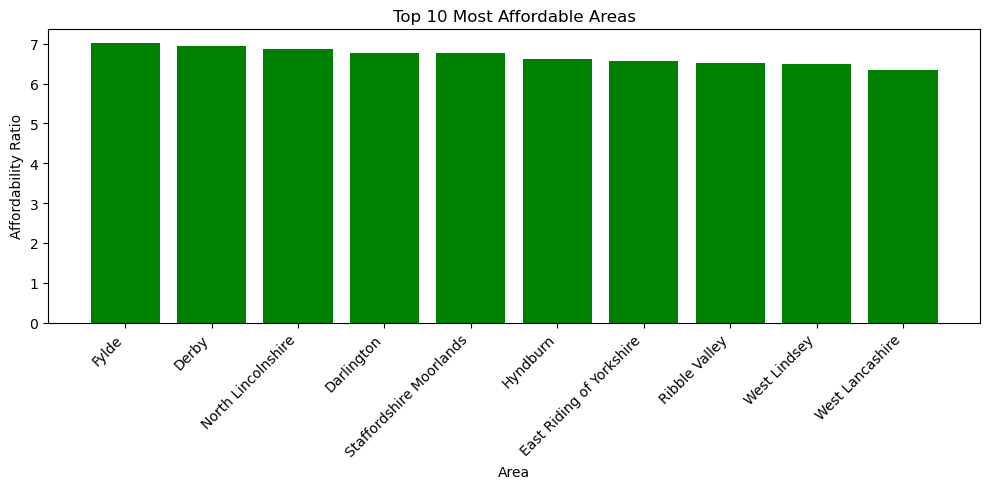

In [451]:
plt.figure(figsize=(10,5))
plt.bar(top_affordable["area"], top_affordable["affordability_ratio"], color='green')
plt.title("Top 10 Most Affordable Areas")
plt.xlabel("Area")  
plt.ylabel("Affordability Ratio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

In [452]:
least_affordable = affordability_sorted.tail(10)
print(least_affordable)

                       area  affordability_ratio
126                 Lambeth             2.745714
38                   Camden             2.692857
67                   Ealing             2.682857
100                Haringey             2.668333
98   Hammersmith and Fulham             2.615714
266             Westminster             2.588333
254              Wandsworth             2.561429
96                  Hackney             2.557143
154                  Newham             2.488571
120  Kensington and Chelsea             1.904000


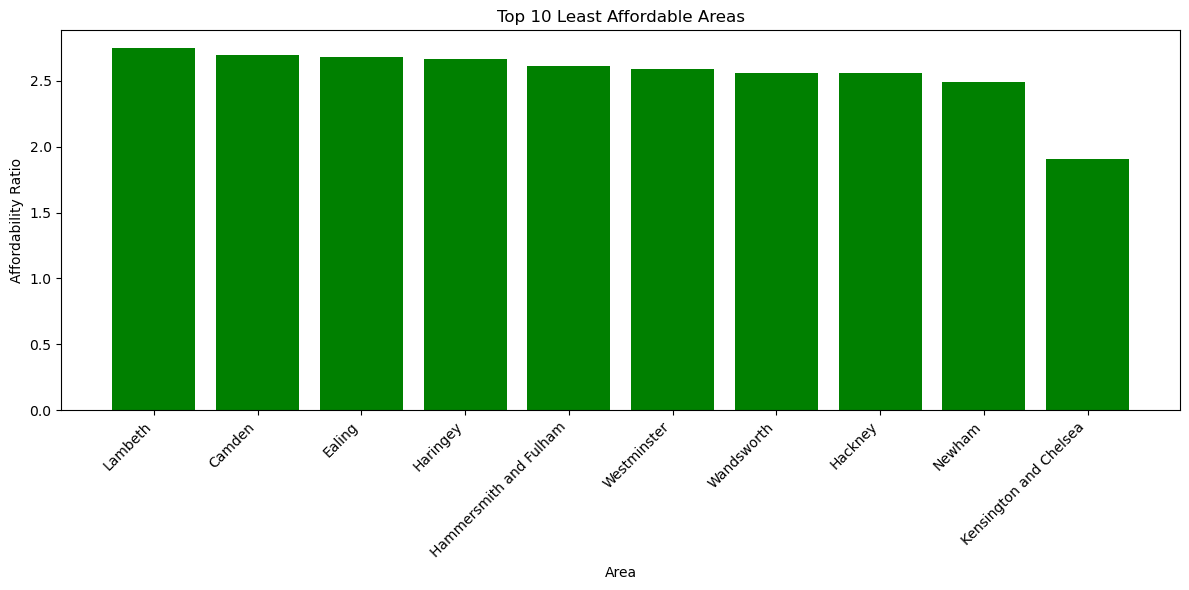

In [453]:
plt.figure(figsize=(12,6))
plt.bar(least_affordable["area"], least_affordable["affordability_ratio"], color='green')
plt.title("Top 10 Least Affordable Areas")
plt.xlabel("Area")  
plt.ylabel("Affordability Ratio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

### 3b. Distribution of rent burden
Histogram with KDE showing the spread of rent burden across all LAs
and years. The 30% threshold line shows what share of observations
represent housing stress.

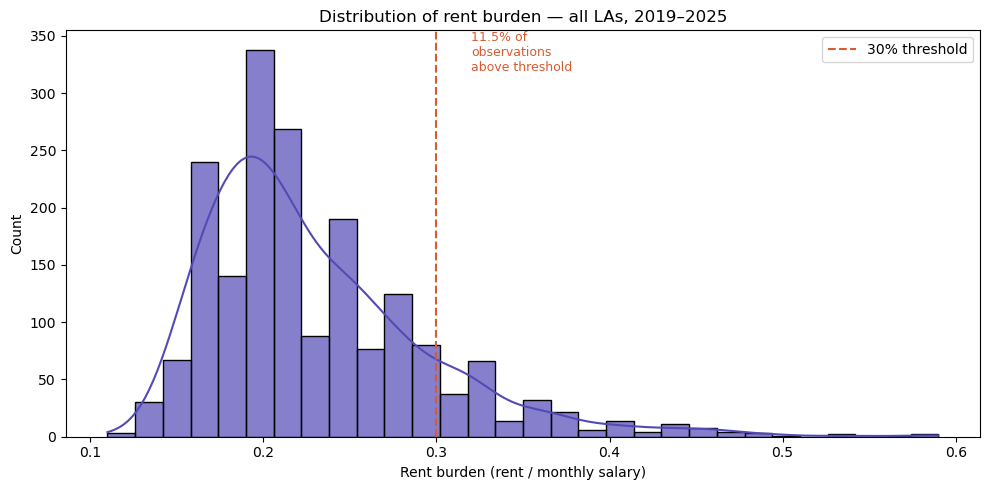

In [454]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df["rent_burden"],
    bins=30,
    kde=True,
    color="#534AB7",
    alpha=0.7,
    ax=ax
)

ax.axvline(0.30, color="#D85A30", linewidth=1.5,
           linestyle="--", label="30% threshold")

pct_above = (df["rent_burden"] > 0.30).mean() * 100
ax.text(0.32, ax.get_ylim()[1] * 0.9,
        f"{pct_above:.1f}% of\nobservations\nabove threshold",
        fontsize=9, color="#D85A30")

ax.set_xlabel("Rent burden (rent / monthly salary)")
ax.set_ylabel("Count")
ax.set_title("Distribution of rent burden — all LAs, 2019–2025")
ax.legend()
plt.tight_layout()
plt.show()

### 3c. National affordability trend over time
Mean rent burden across all LAs by year. Identifies the 2023 structural
break — the sharpest single-year deterioration in the dataset.

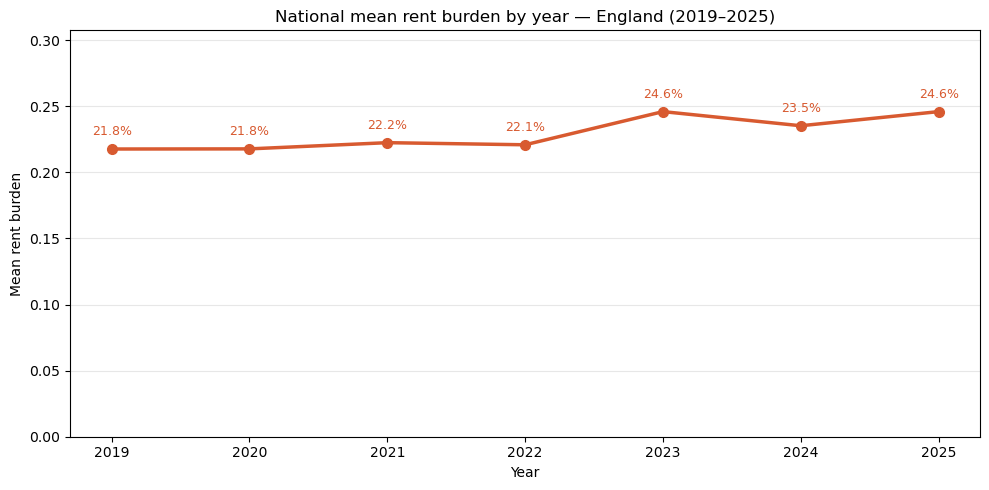

   year  rent_burden  affordability_ratio
0  2019       0.2177               4.8504
1  2020       0.2178               4.8744
2  2021       0.2225               4.7226
3  2022       0.2209               4.7610
4  2023       0.2460               4.4001
5  2024       0.2353               4.5727
6  2025       0.2460               4.4007


In [455]:
yearly_mean = (
    df.groupby("year")[["rent_burden", "affordability_ratio"]]
    .mean()
    .round(4)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(yearly_mean["year"], yearly_mean["rent_burden"],
        marker="o", color="#D85A30", linewidth=2.5,
        markersize=7, label="Mean rent burden")

for _, row in yearly_mean.iterrows():
    ax.annotate(
        f"{row['rent_burden']:.1%}",
        xy=(row["year"], row["rent_burden"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=9, color="#D85A30"
    )

ax.set_xlabel("Year")
ax.set_ylabel("Mean rent burden")
ax.set_title("National mean rent burden by year — England (2019–2025)")
ax.set_xticks(yearly_mean["year"])
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, yearly_mean["rent_burden"].max() * 1.25)
plt.tight_layout()
plt.show()

print(yearly_mean)

### 3d. Rent vs salary by year
Scatter plot of monthly median rent against monthly median salary,
coloured by year. Shows whether rent and salary have grown in tandem
or whether rent has outpaced earnings.

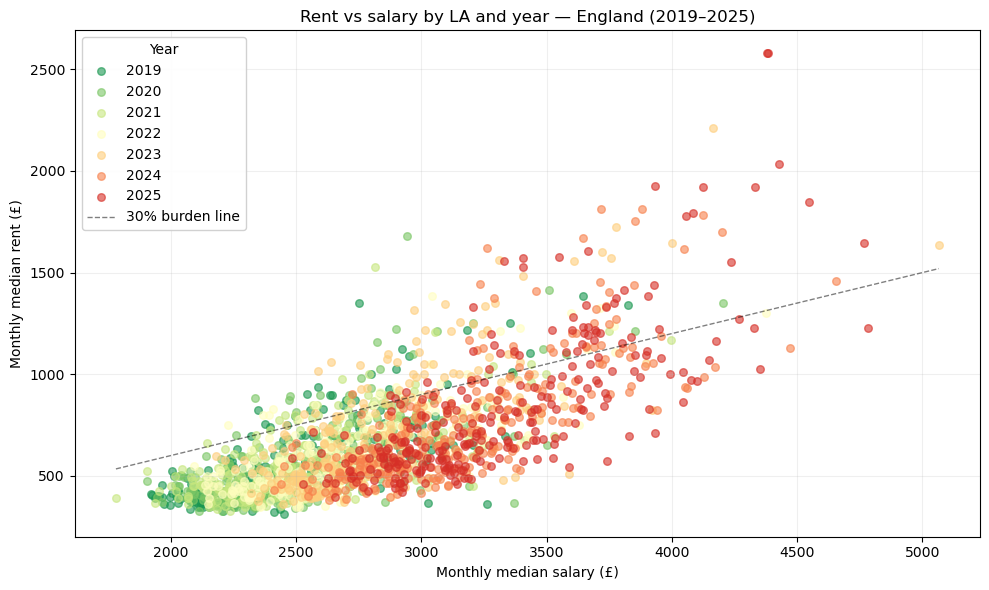

In [456]:
fig, ax = plt.subplots(figsize=(10, 6))

years = sorted(df["year"].unique())
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(years)))

for yr, color in zip(years, palette):
    subset = df[df["year"] == yr]
    ax.scatter(
        subset["monthly_median_salary"],
        subset["monthly_median_rent"],
        color=color, alpha=0.6, s=30, label=str(int(yr))
    )

# 30% burden reference line
x_range = np.linspace(df["monthly_median_salary"].min(),
                       df["monthly_median_salary"].max(), 100)
ax.plot(x_range, x_range * 0.30, color="black",
        linewidth=1, linestyle="--", alpha=0.5,
        label="30% burden line")

ax.set_xlabel("Monthly median salary (£)")
ax.set_ylabel("Monthly median rent (£)")
ax.set_title("Rent vs salary by LA and year — England (2019–2025)")
ax.legend(title="Year", framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 3e. Rent burden spread by year
Boxplot showing the distribution of rent burden across LAs for each year.
Reveals whether the 2023 spike was driven by outliers or a broad shift.

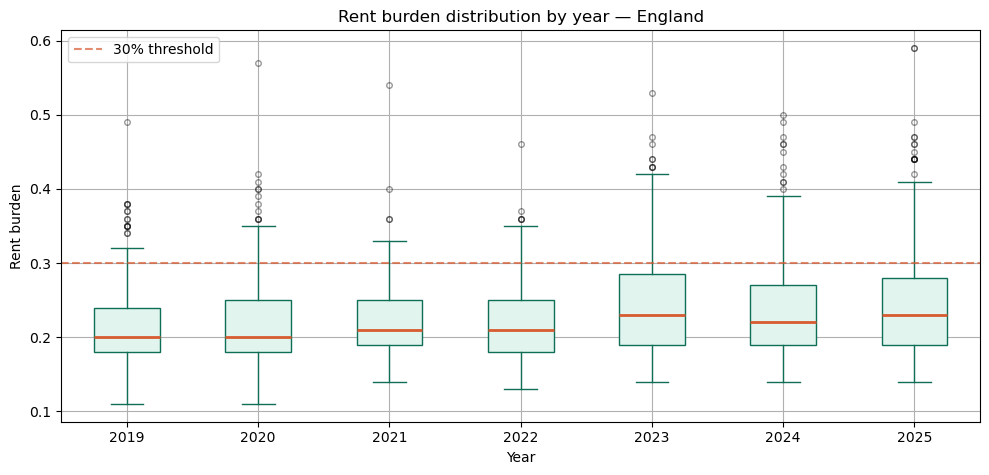

In [457]:
fig, ax = plt.subplots(figsize=(10, 5))

df.boxplot(
    column="rent_burden",
    by="year",
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor="#E1F5EE", color="#0F6E56"),
    medianprops=dict(color="#D85A30", linewidth=2),
    whiskerprops=dict(color="#0F6E56"),
    capprops=dict(color="#0F6E56"),
    flierprops=dict(marker="o", color="#D85A30",
                    alpha=0.4, markersize=4)
)

ax.axhline(AFFORDABILITY_THRESHOLD, color="#D85A30",
           linewidth=1.5, linestyle="--", alpha=0.7,
           label="30% threshold")

ax.set_title("Rent burden distribution by year — England")
ax.set_xlabel("Year")
ax.set_ylabel("Rent burden")
plt.suptitle("")
ax.legend()
plt.tight_layout()
plt.show()

In [458]:
df = df.copy()

### 3f. Correlation matrix
Pairwise correlations between the key affordability metrics.
Confirms expected relationships and checks for multicollinearity
before segmentation.

In [459]:
rent_growth = (
    df.sort_values(["area_code", "year"])
    .groupby("area_code")["monthly_median_rent"]
    .pct_change()          # YoY % change, NaN for first year of each LA
    .rename("rent_growth_rate")
)

df["rent_growth_rate"] = rent_growth.values

growth_by_area = (
    df.groupby("area_code")["rent_growth_rate"]
    .mean()
    .rename("mean_rent_growth")
)

print(growth_by_area.describe().round(4))
print(f"\nNaN areas (insufficient years): {growth_by_area.isna().sum()}")

count    281.0000
mean       0.0751
std        0.0225
min        0.0115
25%        0.0593
50%        0.0743
75%        0.0900
max        0.1404
Name: mean_rent_growth, dtype: float64

NaN areas (insufficient years): 0


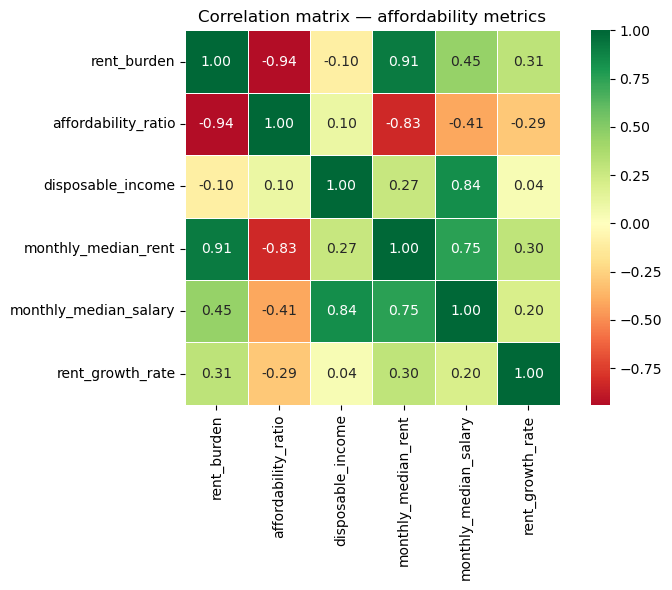

In [460]:
corr_cols = [
    "rent_burden", "affordability_ratio",
    "disposable_income", "monthly_median_rent",
    "monthly_median_salary", "rent_growth_rate"
]

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    ax=ax,
    linewidths=0.5,
    square=True
)

ax.set_title("Correlation matrix — affordability metrics")
plt.tight_layout()
plt.show()

### 3g. EDA summary

Key findings before modelling:

- **Mean rent burden** across England is approximately 22%, but the
  distribution is right-skewed — a minority of LAs drive the average up.
- **2023 structural break**: the share of LAs above the 30% threshold
  nearly doubled in a single year (6.8% → 17.1%), consistent with the
  post-pandemic private rent surge.
- **Regional inequality is stark**: affordability ratios range from ~2x
  in the least affordable LAs to ~7x in the most affordable — a 3.5x gap.
- **Rent and salary are not growing in tandem**: the scatter plot shows
  rent pulling away from the 30% reference line in recent years,
  particularly in southern England.
- **The 2023 spike was broad, not outlier-driven**: the boxplot shows
  the entire distribution shifted upward in 2023, not just the extremes.

## 4. Clustering Algorithm

K-means clustering is applied based on the number of clusters obtained by Elbow plot and silhouette score.

In [461]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [462]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Aggregate per area — mean across years for each feature
cluster_input = df.groupby(["area_code", "area"]).agg(
    affordability_ratio=("affordability_ratio", "mean"),
    rent_burden=("rent_burden", "mean"),
    disposable_income=("disposable_income", "mean"),
    mean_rent_growth=("rent_growth_rate", "mean")
).dropna().reset_index()

print(f"Areas in clustering matrix: {len(cluster_input)}")
print(cluster_input[["affordability_ratio", "rent_burden",
                      "disposable_income", "mean_rent_growth"]].describe().round(3))

Areas in clustering matrix: 281
       affordability_ratio  rent_burden  disposable_income  mean_rent_growth
count              281.000      281.000            281.000           281.000
mean                 4.642        0.230           2137.004             0.075
std                  1.039        0.060            197.003             0.023
min                  1.904        0.143           1481.400             0.011
25%                  3.953        0.187           1993.143             0.059
50%                  4.676        0.217           2125.357             0.074
75%                  5.395        0.256           2253.571             0.090
max                  7.014        0.530           2768.071             0.140


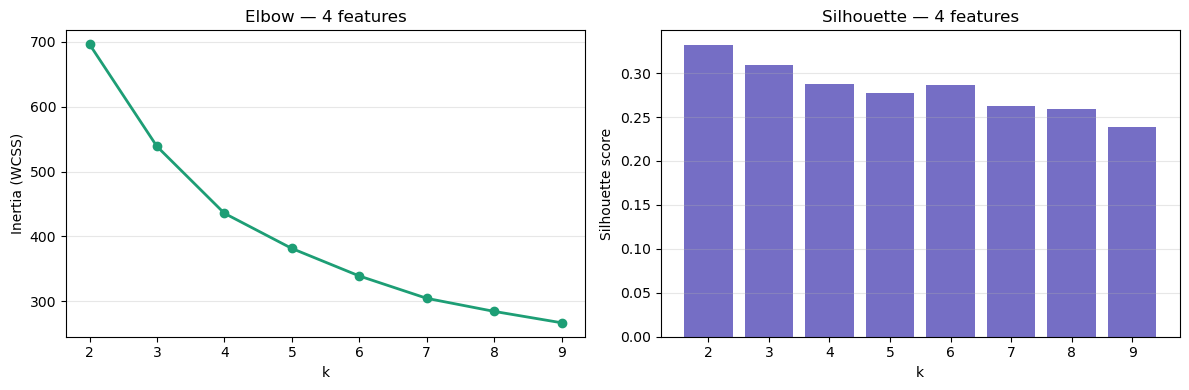

Best k by silhouette: 2
  k=2  silhouette=0.3320
  k=3  silhouette=0.3087
  k=4  silhouette=0.2878
  k=5  silhouette=0.2772
  k=6  silhouette=0.2861
  k=7  silhouette=0.2626
  k=8  silhouette=0.2594
  k=9  silhouette=0.2383


In [463]:
from sklearn.metrics import silhouette_score

features = ["affordability_ratio", "rent_burden",
            "disposable_income", "mean_rent_growth"]

X4 = cluster_input[features].copy()
scaler = StandardScaler()
X4_scaled = scaler.fit_transform(X4)

inertia, sil_scores = [], []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X4_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X4_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertia, marker="o", color="#1D9E75", linewidth=2)
ax1.set_title("Elbow — 4 features")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_xticks(list(k_range))
ax1.grid(axis="y", alpha=0.3)

ax2.bar(list(k_range), sil_scores, color="#534AB7", alpha=0.8)
ax2.set_title("Silhouette — 4 features")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
ax2.set_xticks(list(k_range))
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette: {best_k}")
for k, s in zip(k_range, sil_scores):
    print(f"  k={k}  silhouette={s:.4f}")

In [464]:
X = df.groupby("area")[["affordability_ratio", "rent_burden"]].mean()

kmeans = KMeans(n_clusters=2, random_state=42)
X["cluster"] = kmeans.fit_predict(X)

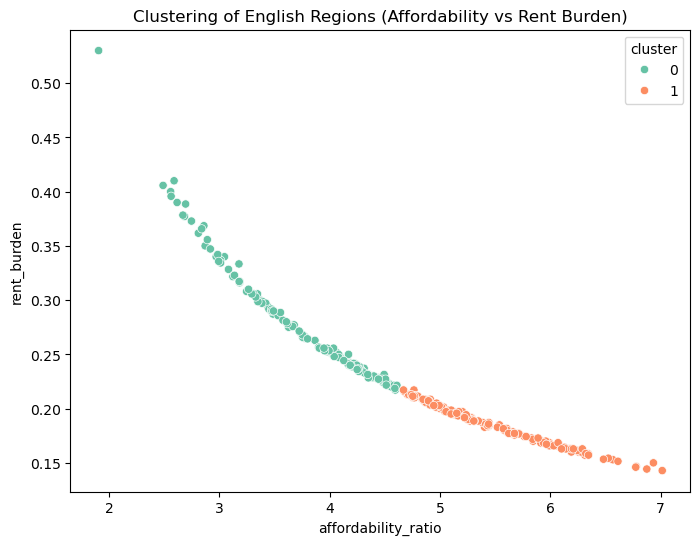

In [465]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=X,
    x="affordability_ratio",
    y="rent_burden",
    hue="cluster",
    palette="Set2"
)

plt.title("Clustering of English Regions (Affordability vs Rent Burden)")
plt.show()

This plot motivated the switch to threshold-based segmentation.

## 5. Segmentation : threshold-based behavioural classification

KMeans clustering on continuous features (affordability ratio, rent burden)
returned k=2 regardless of feature richness.

England has a genuine binary structure driven by the London/South East divide. Forcing k=2 would produce an arbitrary geometric split, not a meaningful grouping.

Instead, LAs are segmented by their **behaviour relative to the 30%
threshold over time**. This produces four interpretable groups with a
direct policy narrative:

| Segment | Definition |
|---|---|
| Always affordable | Never exceeded 30% in any year |
| Always high pressure | Exceeded 30% in every year |
| Deteriorating | Below 30% in 2019, above in at least one later year |
| Improving | Above 30% in 2019, below in at least one later year |

### 5a. Building threshold flag matrix and assigning segments

In [466]:
# One row per LA, one column per year — value is 1 if rent_burden > 0.3
threshold = 0.30

burden_pivot = (
    df.pivot_table(
        index=["area_code", "area"],
        columns="year",
        values="rent_burden",
        aggfunc="mean"
    )
)

flag_pivot = (burden_pivot > threshold).astype(int)

print("Flag matrix (1 = above 30% threshold):")
print(flag_pivot.head(10))
print(f"\nShape: {flag_pivot.shape}")

Flag matrix (1 = above 30% threshold):
year                                   2019  2020  2021  2022  2023  2024  \
area_code area                                                              
E06000001 Hartlepool                      0     0     0     0     0     0   
E06000002 Middlesbrough                   0     0     0     0     0     0   
E06000003 Redcar and Cleveland            0     0     0     0     0     0   
E06000004 Stockton-on-Tees                0     0     0     0     0     0   
E06000005 Darlington                      0     0     0     0     0     0   
E06000006 Halton                          0     0     0     0     0     0   
E06000007 Warrington                      0     0     0     0     0     0   
E06000008 Blackburn with Darwen           0     0     0     0     0     0   
E06000009 Blackpool                       0     0     0     0     0     0   
E06000010 Kingston upon Hull, City of     0     0     0     0     0     0   

year                                

In [467]:
years_sorted = sorted(flag_pivot.columns)
first_year = years_sorted[0]   # 2019
later_years = years_sorted[1:] # 2020 onwards

def assign_segment(row):
    was_above_first = row[first_year] == 1
    ever_above_later = row[later_years].any()
    always_above = row.all()
    never_above = (~row.astype(bool)).all()

    if never_above:
        return "Always affordable"
    elif always_above:
        return "Always high pressure"
    elif not was_above_first and ever_above_later:
        return "Deteriorating"
    elif was_above_first and not row[later_years].all():
        return "Improving"
    else:
        return "Always high pressure"  # above in most years

flag_pivot["segment"] = flag_pivot.apply(assign_segment, axis=1)

print(flag_pivot["segment"].value_counts())

segment
Always affordable       218
Deteriorating            38
Improving                17
Always high pressure      8
Name: count, dtype: int64


In [468]:
segment_lookup = flag_pivot[["segment"]].reset_index()

# Drop segment column if it already exists (re-run safety)
df = df.drop(columns=["segment"], errors="ignore")

df = df.merge(segment_lookup[["area_code", "segment"]],
              on="area_code", how="left")

# Profile: what does each segment look like on average?
profile = (
    df.groupby("segment")[[
        "rent_burden",
        "affordability_ratio",
        "disposable_income",
        "monthly_median_rent"
    ]]
    .mean()
    .round(3)
    .sort_values("rent_burden", ascending=False)
)

print(profile)

                      rent_burden  affordability_ratio  disposable_income  \
segment                                                                     
Always high pressure        0.380                2.680           2065.152   
Improving                   0.351                2.946           2095.636   
Deteriorating               0.292                3.497           2146.204   
Always affordable           0.204                5.057           2138.819   

                      monthly_median_rent  
segment                                    
Always high pressure             1275.991  
Improving                        1187.239  
Deteriorating                     890.930  
Always affordable                 555.257  


### 5b. Plotting the segment scatter plot

LAs plotted by affordability ratio vs rent burden, coloured by segment.
The 30% threshold line separates high-pressure from affordable zones.

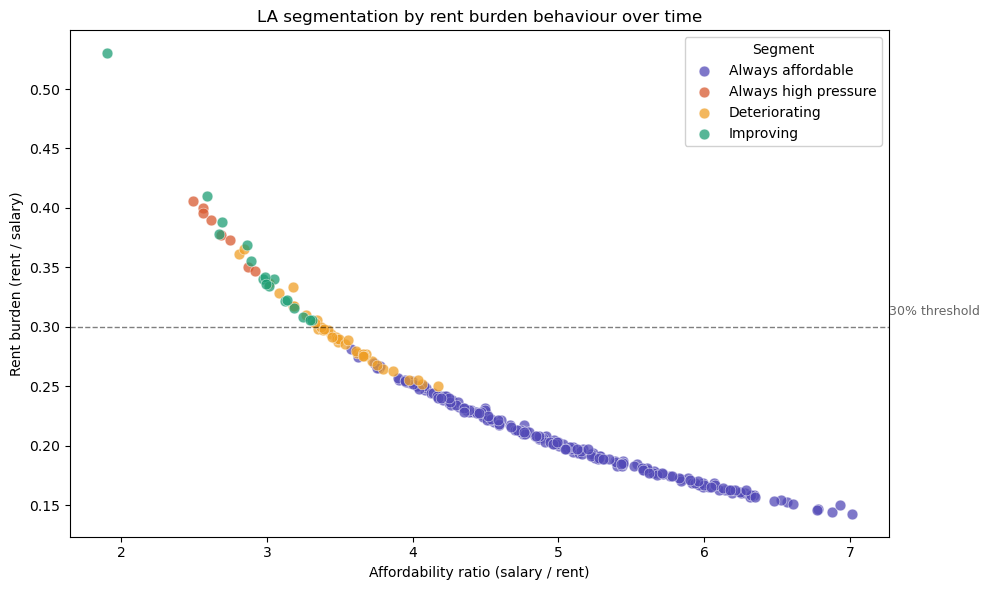

In [469]:
import matplotlib.patches as mpatches

palette = {
    "Always high pressure": "#D85A30",
    "Deteriorating":        "#EF9F27",
    "Improving":            "#1D9E75",
    "Always affordable":    "#534AB7",
}

plot_data = df.groupby(["area_code", "area", "segment"]).agg(
    affordability_ratio=("affordability_ratio", "mean"),
    rent_burden=("rent_burden", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for seg, group in plot_data.groupby("segment"):
    ax.scatter(
        group["affordability_ratio"],
        group["rent_burden"],
        color=palette.get(seg, "#888"),
        label=seg,
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
        s=60
    )

ax.axhline(0.30, color="black", linewidth=1, linestyle="--", alpha=0.5)
ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] > 2 else 7,
        0.31, "30% threshold", fontsize=9, alpha=0.6)

ax.set_xlabel("Affordability ratio (salary / rent)")
ax.set_ylabel("Rent burden (rent / salary)")
ax.set_title("LA segmentation by rent burden behaviour over time")
ax.legend(title="Segment", framealpha=0.9)
plt.tight_layout()
plt.show()

In [470]:
df.to_csv(processed_directory/"housing_affordability_segmented.csv", index=False)

segment_lookup.to_csv(processed_directory/"segment_lookup.csv", index=False)

print("Saved.")
print(df[["area_code", "area", "year", "rent_burden",
          "affordability_ratio", "disposable_income",
          "segment"]].head(10))

Saved.
   area_code           area  year  rent_burden  affordability_ratio  \
0  E06000001     Hartlepool  2019         0.17                 5.77   
1  E06000001     Hartlepool  2020         0.18                 5.65   
2  E06000001     Hartlepool  2021         0.18                 5.63   
3  E06000001     Hartlepool  2022         0.16                 6.06   
4  E06000001     Hartlepool  2023         0.14                 7.26   
5  E06000001     Hartlepool  2024         0.14                 6.91   
6  E06000001     Hartlepool  2025         0.15                 6.67   
7  E06000002  Middlesbrough  2019         0.16                 6.10   
8  E06000002  Middlesbrough  2020         0.16                 6.11   
9  E06000002  Middlesbrough  2021         0.17                 5.87   

   disposable_income            segment  
0             1792.0  Always affordable  
1             1927.0  Always affordable  
2             1942.0  Always affordable  
3             2096.0  Always affordable  
4

### 5c. Tipping point analysis

LAs that crossed the 30% threshold for the first time in each year.
Identifies when and where affordability deteriorated most sharply.

In [471]:
tipping_records = []

for i in range(len(years_sorted) - 1):
    yr_before = years_sorted[i]
    yr_after  = years_sorted[i + 1]

    tipped = flag_pivot[
        (flag_pivot[yr_before] == 0) &
        (flag_pivot[yr_after]  == 1)
    ].index.get_level_values("area").tolist()

    for area in tipped:
        tipping_records.append({
            "area":      area,
            "tipped_in": yr_after
        })

tipping_df = pd.DataFrame(tipping_records)

print("=== Tipping point LAs by year ===")
print(
    tipping_df.groupby("tipped_in")["area"]
    .apply(lambda x: list(x))
)
print(f"\nTotal LAs that crossed threshold at least once: "
      f"{tipping_df['area'].nunique()}")

tipping_df.to_csv(processed_directory/"tipping_points.csv",
    index=False
)

=== Tipping point LAs by year ===
tipped_in
2020    [Castle Point, Epping Forest, Broxbourne, Thre...
2021    [Dacorum, Sevenoaks, Reigate and Banstead, Tan...
2022                      [Castle Point, Watford, Camden]
2023    [Bath and North East Somerset, Bristol, City o...
2024    [Hertsmere, Tandridge, Manchester, Harrow, Kin...
2025    [Bath and North East Somerset, Reading, Slough...
Name: area, dtype: object

Total LAs that crossed threshold at least once: 55


In [472]:
print("=== Segment counts ===")
print(flag_pivot["segment"].value_counts())

print("\n=== Segment profiles ===")
print(profile)

print("\n=== Deteriorating LAs ===")
print(
    df[df["segment"] == "Deteriorating"]
    ["area"].unique()
)

print("\n=== Improving LAs ===")
print(
    df[df["segment"] == "Improving"]
    ["area"].unique()
)

=== Segment counts ===
segment
Always affordable       218
Deteriorating            38
Improving                17
Always high pressure      8
Name: count, dtype: int64

=== Segment profiles ===
                      rent_burden  affordability_ratio  disposable_income  \
segment                                                                     
Always high pressure        0.380                2.680           2065.152   
Improving                   0.351                2.946           2095.636   
Deteriorating               0.292                3.497           2146.204   
Always affordable           0.204                5.057           2138.819   

                      monthly_median_rent  
segment                                    
Always high pressure             1275.991  
Improving                        1187.239  
Deteriorating                     890.930  
Always affordable                 555.257  

=== Deteriorating LAs ===
['Bath and North East Somerset' 'Bristol, City of' 

### Key findings

Of 281 English local authorities analysed (2019–2025):
- 218 (78%) remained consistently affordable (rent burden < 30%)
- 38 (14%) are deteriorating — affordable in 2019 but worsening
- 17 (6%) are improving — predominantly London boroughs
- 8 (3%) have been persistently high pressure throughout

The deteriorating group includes Bristol, Reading, Bath, and Slough,
mid-sized cities experiencing London spillover pressure.
These represent the highest-risk areas for renters over the next 3 years.

In [473]:
threshold = 0.30

yearly_counts = (
    df.groupby("year")
    .apply(lambda g: (g["rent_burden"] > threshold).sum())
    .reset_index()
    .rename(columns={0: "las_above_threshold"})
)

total_las = df["area_code"].nunique()
yearly_counts["pct_above"] = (
    yearly_counts["las_above_threshold"] / total_las * 100
).round(1)

print(yearly_counts)

   year  las_above_threshold  pct_above
0  2019                   25        8.9
1  2020                   23        8.2
2  2021                   26        9.3
3  2022                   19        6.8
4  2023                   48       17.1
5  2024                   36       12.8
6  2025                   50       17.8


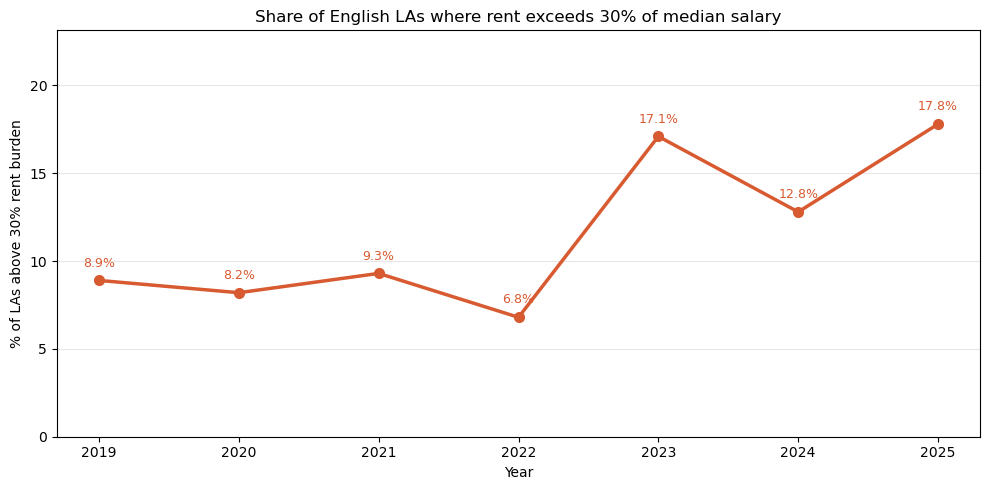

In [474]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    yearly_counts["year"],
    yearly_counts["pct_above"],
    marker="o",
    color="#D85A30",
    linewidth=2.5,
    markersize=7
)

for _, row in yearly_counts.iterrows():
    ax.annotate(
        f"{row['pct_above']}%",
        xy=(row["year"], row["pct_above"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color="#D85A30"
    )

ax.set_xlabel("Year")
ax.set_ylabel("% of LAs above 30% rent burden")
ax.set_title("Share of English LAs where rent exceeds 30% of median salary")
ax.set_xticks(yearly_counts["year"])
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, yearly_counts["pct_above"].max() * 1.3)
plt.tight_layout()
plt.show()

Temporal findings

2019–2022: Stable pressure — 7–9% of LAs above 30% threshold.
Tipping confined to Essex/Hertfordshire commuter belt.

Bristol, Bath, Reading, Slough cross for the first time.
Likely driven by post-pandemic private rent surge (2022-23).
024-2025: Pressure persists — 13–18% range, no sign of recovery.
Manchester enters in 2024 — first major Northern city to tip.
38 LAs classified as deteriorating; none have sustainably recovered.

Policy implication: the affordability crisis is no longer London-centric.
Mid-sized regional cities are now experiencing structural rent pressure.

## 6. Forecasting : linear trend projection (2026–2028)

ARIMA(1,1,0) on 7 annual data points defaults to a flat forecast. With n=7, parameter estimation is unreliable.

**Approach:** OLS linear regression (year → rent burden) fitted per LA.
Captures each LA's actual slope over 2019–2025 and extrapolates forward.
Prediction intervals derived from RMSE of the training fit (80% level).

**Limitation:** Linear trend assumes no structural breaks post-2025.
The 2023 spike suggests non-linearity, forecasts should be interpreted
directionally, not as precise predictions.

**Use case:** Identifying which currently-affordable LAs are on a
trajectory to cross the 30% threshold by 2028.

### 6a. Fitting a linear trend model per LA

In [475]:
from sklearn.linear_model import LinearRegression
import numpy as np

forecast_records = []
forecast_years = [2026, 2027, 2028]
all_years = sorted(df["year"].unique())

las = (
    df.groupby("area_code")["year"]
    .nunique()
    .loc[lambda x: x == df["year"].nunique()]
    .index.tolist()
)

print(f"LAs with complete year coverage: {len(las)}")

for area_code in las:
    area_df = (
        df[df["area_code"] == area_code]
        .sort_values("year")
        [["year", "rent_burden", "area", "segment"]]
        .drop_duplicates("year")
        .dropna(subset=["rent_burden"])
    )

    if len(area_df) < 4:
        print(f"Skipping {area_code} — insufficient clean data points")
        continue

    area_name = area_df["area"].iloc[0]
    segment   = area_df["segment"].iloc[0]

    X = area_df["year"].values.reshape(-1, 1)
    y = area_df["rent_burden"].values

    model = LinearRegression()
    model.fit(X, y)

    # Residual std — used for prediction interval
    y_pred_train = model.predict(X)
    residuals    = y - y_pred_train
    rmse         = np.sqrt(np.mean(residuals ** 2))

    X_fc = np.array(forecast_years).reshape(-1, 1)
    y_fc = model.predict(X_fc)

    # 80% prediction interval (~1.28 * rmse)
    margin = 1.28 * rmse

    for i, yr in enumerate(forecast_years):
        forecast_records.append({
            "area_code":            area_code,
            "area":                 area_name,
            "segment":              segment,
            "year":                 yr,
            "rent_burden_forecast": round(float(y_fc[i]), 4),
            "ci_lower":             round(float(max(y_fc[i] - margin, 0)), 4),
            "ci_upper":             round(float(y_fc[i] + margin), 4),
            "slope":                round(float(model.coef_[0]), 6),
            "above_30_forecast":    float(y_fc[i]) > 0.30
        })

forecast_df = pd.DataFrame(forecast_records)
print(f"Forecast records: {len(forecast_df)}")
print(forecast_df.head(10))

LAs with complete year coverage: 281
Skipping E07000214 — insufficient clean data points
Forecast records: 840
   area_code                  area            segment  year  \
0  E06000001            Hartlepool  Always affordable  2026   
1  E06000001            Hartlepool  Always affordable  2027   
2  E06000001            Hartlepool  Always affordable  2028   
3  E06000002         Middlesbrough  Always affordable  2026   
4  E06000002         Middlesbrough  Always affordable  2027   
5  E06000002         Middlesbrough  Always affordable  2028   
6  E06000003  Redcar and Cleveland  Always affordable  2026   
7  E06000003  Redcar and Cleveland  Always affordable  2027   
8  E06000003  Redcar and Cleveland  Always affordable  2028   
9  E06000004      Stockton-on-Tees  Always affordable  2026   

   rent_burden_forecast  ci_lower  ci_upper     slope  above_30_forecast  
0                0.1343    0.1220    0.1466 -0.006429              False  
1                0.1279    0.1156    0.1401 -

### 6b. At-risk LAs

Currently affordable LAs projected to cross the 30% threshold
by 2028 under current trend conditions.

In [476]:
currently_affordable = df[
    (df["year"] == 2025) &
    (df["rent_burden"] <= 0.30)
]["area_code"].unique()

at_risk = (
    forecast_df[
        (forecast_df["area_code"].isin(currently_affordable)) &
        (forecast_df["above_30_forecast"] == True)
    ]
    .groupby(["area_code", "area", "segment"])
    .agg(
        projected_crossing_year=("year", "min"),
        forecast_burden_2028=("rent_burden_forecast", "max"),
        slope=("slope", "first")
    )
    .reset_index()
    .sort_values("projected_crossing_year")
)

print("=== LAs projected to cross 30% by 2028 ===")
print(at_risk[["area", "segment",
               "projected_crossing_year",
               "forecast_burden_2028",
               "slope"]].to_string(index=False))

forecast_df.to_csv(
    processed_directory / "rent_burden_forecast.csv",
    index=False
)
at_risk.to_csv(
    processed_directory / "at_risk_las.csv",
    index=False
)
yearly_counts.to_csv(
    processed_directory / "yearly_threshold_counts.csv",
    index=False
)

=== LAs projected to cross 30% by 2028 ===
                 area           segment  projected_crossing_year  forecast_burden_2028    slope
                Luton Always affordable                     2026                0.3600 0.021429
           Portsmouth Always affordable                     2026                0.3307 0.015357
             Rushmoor Always affordable                     2026                0.3356 0.016571
            Maidstone Always affordable                     2026                0.3271 0.012857
Tonbridge and Malling     Deteriorating                     2026                0.3253 0.008286
              Dacorum     Deteriorating                     2026                0.3164 0.003214
               Harlow Always affordable                     2026                0.3329 0.008571
                 Adur     Deteriorating                     2026                0.3300 0.005000
             Worthing Always affordable                     2026                0.3264 0.0117

### 6c. Forecast plots : Deteriorating LAs
Actuals (2019–2025) connected to linear trend forecast (2026–2028).

Shaded band = 80% prediction interval. Dotted line = 30% threshold.

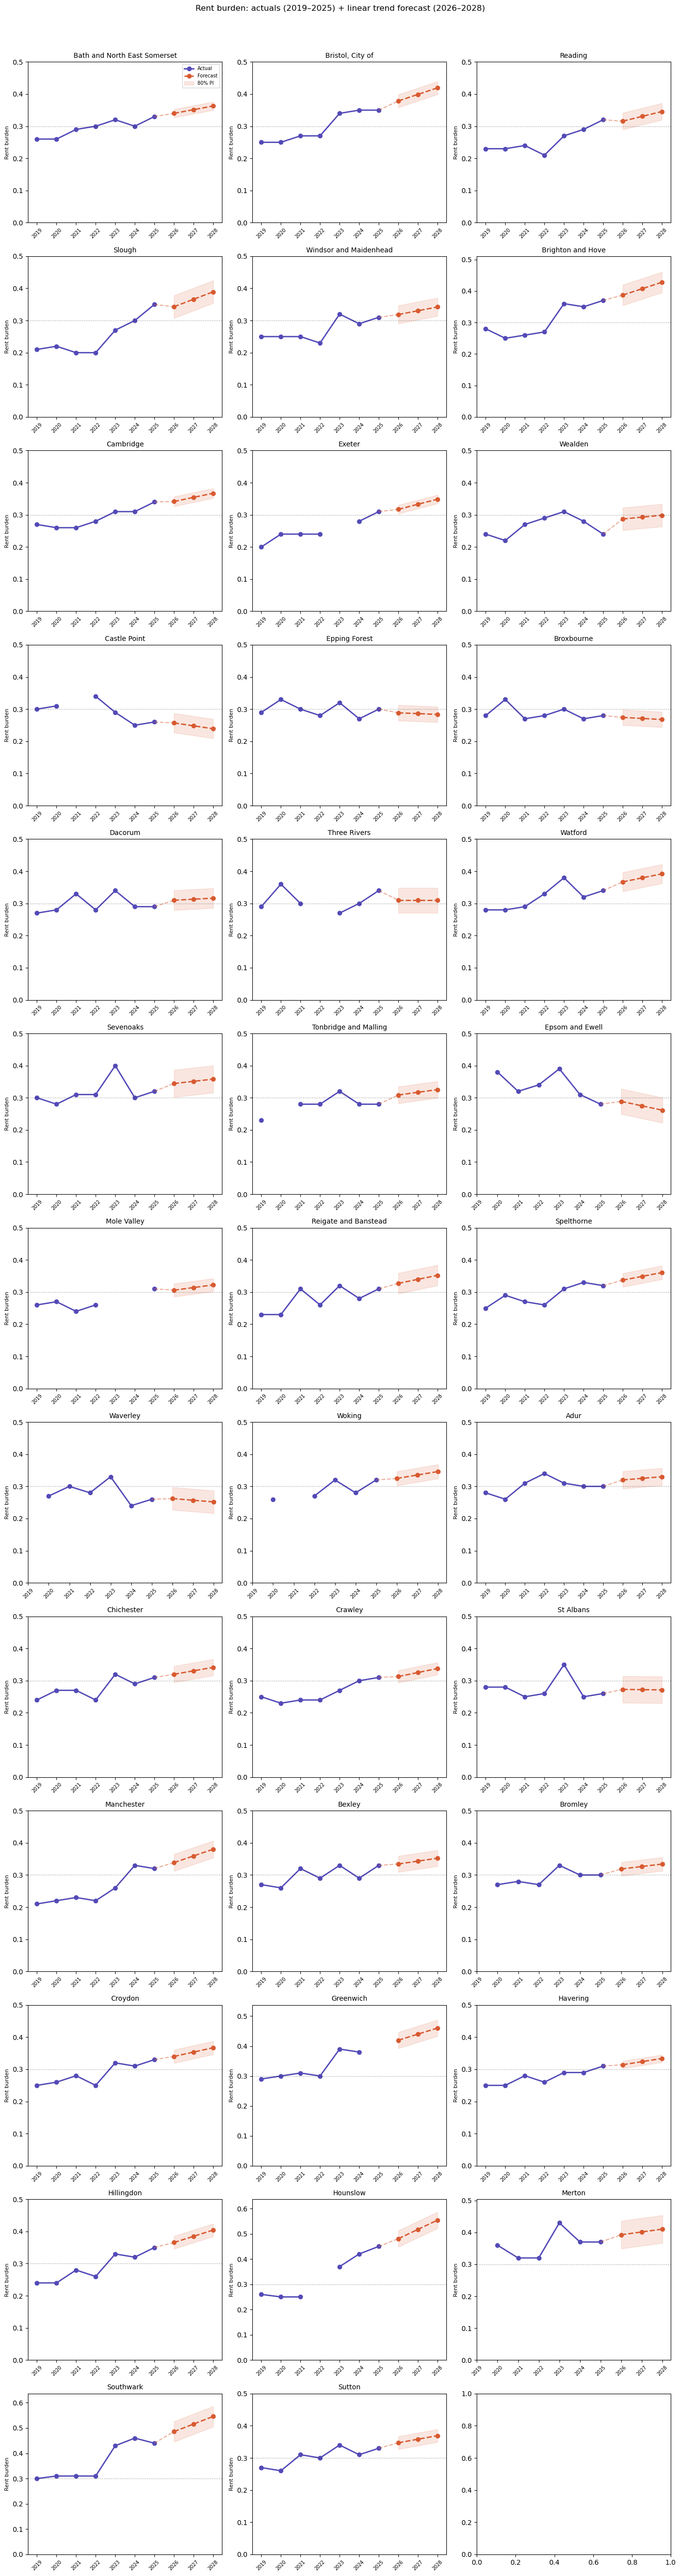

In [477]:
focus_areas = list(
    df[df["segment"] == "Deteriorating"]["area"].unique()
)

n = len(focus_areas)
cols = 3
rows = (n + cols - 1) // cols  # ceiling division
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
axes = axes.flatten()

for i, area in enumerate(focus_areas):
    ax = axes[i]

    actuals = (
        df[df["area"] == area]
        .sort_values("year")
        [["year", "rent_burden"]]
        .drop_duplicates("year")
    )

    fc = forecast_df[forecast_df["area"] == area]

    # Connect actuals to forecast with a bridge point
    bridge_x = [actuals["year"].iloc[-1], fc["year"].iloc[0]]
    bridge_y = [actuals["rent_burden"].iloc[-1],
                fc["rent_burden_forecast"].iloc[0]]

    ax.plot(actuals["year"], actuals["rent_burden"],
            marker="o", color="#534AB7", linewidth=2, label="Actual")

    ax.plot(bridge_x, bridge_y,
            linestyle="--", color="#D85A30", linewidth=1.5, alpha=0.5)

    ax.plot(fc["year"], fc["rent_burden_forecast"],
            marker="o", linestyle="--", color="#D85A30",
            linewidth=2, label="Forecast")

    ax.fill_between(
        fc["year"],
        fc["ci_lower"],
        fc["ci_upper"],
        alpha=0.15,
        color="#D85A30",
        label="80% PI"
    )

    ax.axhline(0.30, color="black", linewidth=1,
               linestyle=":", alpha=0.4)

    ax.set_title(area, fontsize=10)
    ax.set_xticks(list(all_years) + forecast_years)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.set_ylabel("Rent burden", fontsize=8)
    ax.set_ylim(0, max(0.50, fc["ci_upper"].max() + 0.05))

    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    "Rent burden: actuals (2019–2025) + linear trend forecast (2026–2028)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

## 7. Key findings

### Segmentation
| Segment | Count | Share |
|---|---|---|
| Always affordable | 218 | 78% |
| Deteriorating | 38 | 14% |
| Improving | 17 | 6% |
| Always high pressure | 8 | 3% |

### Temporal findings
- **2019–2022:** Stable : 7–9% of LAs above threshold. Pressure confined
  to Essex/Hertfordshire commuter belt and inner London.
- **2023:** Sharp deterioration : 17.1% of LAs above threshold, up from
  6.8% in 2022. Bristol, Bath, Reading, Slough cross for the first time.
  Consistent with the post-pandemic private rent surge.
- **2024–2025:** Pressure persists at 13–18%. Manchester enters in 2024,
  first major Northern city to cross the threshold.
- **No sustained recovery observed** in any deteriorating LA across the
  dataset period.

### Forecasting
- Linear trend projection (2026–2028) flags LAs on a trajectory to cross
  the 30% threshold under current conditions.
- The affordability crisis is no longer London-centric, mid-sized regional
  cities (Bristol, Manchester, Brighton) now show structural rent pressure.

### Limitations
- Rent data methodology changes between 2022 and 2023 (three bedroom
  categories → 1-bed only) may introduce a small level shift.
- Linear trend projection assumes no structural breaks post-2025.
- Analysis covers England only, Wales, Scotland, and Northern Ireland
  use different administrative geographies.